# 03 — Draft Cohort ROI (Pillar 2)
**Question:** Is the Mariners development pipeline producing value relative to draft slot?

**Approach:** Pure SQL in DuckDB. Draft classes 2013–2025. MLB reach rate, WAR accumulated per draft slot vs league average. Heavy use of window functions and CTEs.

In [1]:
import sys
sys.path.insert(0, "..")

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from src.ingest.pull_data import get_db

try:
    con = get_db(read_only=True)
except duckdb.IOException as e:
    print("⚠  DuckDB lock error:", e)
    raise

n_picks = con.execute("SELECT COUNT(*) FROM draft_picks").fetchone()[0]
if n_picks == 0:
    print("⚠  draft_picks is empty.")
    print("Run:  python -m src.ingest.pull_data")
    print("That will fetch Baseball Reference draft data for 2013–2020 (~5 min).")
else:
    print(f"✓  draft_picks: {n_picks} rows")
    print(con.execute("""
        SELECT season, COUNT(*) AS picks,
               SUM(reached_mlb::INT) AS reached_mlb,
               COUNT(DISTINCT team) AS teams
        FROM draft_picks
        GROUP BY season ORDER BY season
    """).fetchdf().to_string(index=False))

✓  draft_picks: 7540 rows
 season  picks  reached_mlb  teams
   2013    616        184.0     36
   2014    615        156.0     30
   2015    615        165.0     30
   2016    616        197.0     30
   2017    615        176.0     30
   2018    614        168.0     30
   2019    617        169.0     30
   2020    160         73.0     30
   2021    612        125.0     30
   2022    616         78.0     30
   2023    614         31.0     30
   2024    615         12.0     30
   2025    615          0.0     30


## 1 — MLB Reach Rate by Draft Class

What percentage of drafted players (rounds 1–10) eventually appeared in an MLB game?
Mariners vs league average, by draft year.

In [2]:
reach_df = con.execute("""
    WITH cohort AS (
        SELECT
            season,
            team,
            COUNT(*)                          AS picks,
            SUM(reached_mlb::INT)             AS mlb_picks
        FROM draft_picks
        WHERE round <= 10
        GROUP BY season, team
    ),
    league AS (
        SELECT
            season,
            SUM(picks)                              AS league_picks,
            SUM(mlb_picks)                          AS league_mlb,
            ROUND(100.0 * SUM(mlb_picks)
                  / NULLIF(SUM(picks), 0), 1)       AS league_reach_pct
        FROM cohort
        GROUP BY season
    ),
    mariners AS (
        SELECT season,
               picks          AS sea_picks,
               mlb_picks      AS sea_mlb,
               ROUND(100.0 * mlb_picks
                     / NULLIF(picks, 0), 1)         AS sea_reach_pct
        FROM cohort
        WHERE team = 'Mariners'
    )
    SELECT
        l.season,
        l.league_picks,
        l.league_mlb,
        l.league_reach_pct,
        m.sea_picks,
        m.sea_mlb,
        m.sea_reach_pct
    FROM league l
    LEFT JOIN mariners m USING (season)
    ORDER BY l.season
""").fetchdf()

print(reach_df.to_string(index=False))

 season  league_picks  league_mlb  league_reach_pct  sea_picks  sea_mlb  sea_reach_pct
   2013         316.0       137.0              43.4         10      5.0           50.0
   2014         315.0       119.0              37.8         10      3.0           30.0
   2015         315.0       121.0              38.4         10      4.0           40.0
   2016         316.0       138.0              43.7         10      3.0           30.0
   2017         315.0       128.0              40.6         10      4.0           40.0
   2018         314.0       123.0              39.2         10      5.0           50.0
   2019         317.0       123.0              38.8         11      6.0           54.5
   2020         160.0        73.0              45.6          6      3.0           50.0
   2021         312.0        94.0              30.1         10      3.0           30.0
   2022         316.0        65.0              20.6         10      2.0           20.0
   2023         314.0        28.0          

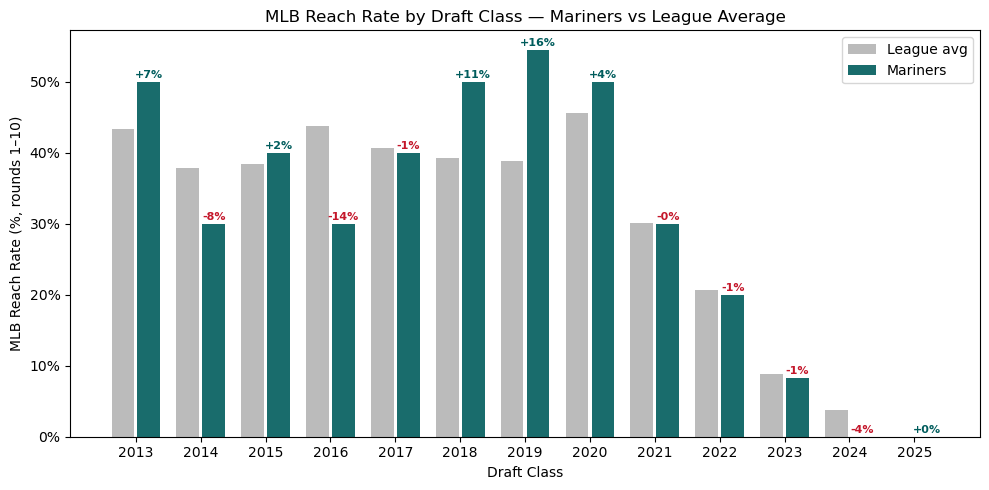

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(reach_df["season"] - 0.2, reach_df["league_reach_pct"],
       width=0.35, color="#AAAAAA", label="League avg", alpha=0.8)
ax.bar(reach_df["season"] + 0.2, reach_df["sea_reach_pct"].fillna(0),
       width=0.35, color="#005C5C", label="Mariners", alpha=0.9)

for _, row in reach_df.iterrows():
    if pd.notna(row["sea_reach_pct"]):
        delta = row["sea_reach_pct"] - row["league_reach_pct"]
        color = "#005C5C" if delta >= 0 else "#C4162A"
        ax.annotate(f"{delta:+.0f}%", (row["season"] + 0.2, row["sea_reach_pct"] + 0.5),
                    ha="center", fontsize=8, color=color, fontweight="bold")

ax.set_xlabel("Draft Class")
ax.set_ylabel("MLB Reach Rate (%, rounds 1–10)")
ax.set_title("MLB Reach Rate by Draft Class — Mariners vs League Average")
ax.set_xticks(reach_df["season"])
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

## 2 — Career WAR per Pick Slot: Mariners vs League

For each overall pick number (1–75), average career MLB WAR accumulated vs league baseline.
Mariners picks above the curve = surplus development value.

In [4]:
war_slot_df = con.execute("""
    WITH pick_war AS (
        SELECT
            dp.season,
            dp.team,
            dp.pick_overall,
            dp.name_at_draft,
            dp.mlbam_id,
            COALESCE(SUM(ps.war), 0)    AS career_war
        FROM draft_picks dp
        LEFT JOIN player_seasons ps USING (mlbam_id)
        WHERE dp.pick_overall <= 75
          AND dp.round <= 3
        GROUP BY dp.season, dp.team, dp.pick_overall, dp.name_at_draft, dp.mlbam_id
    ),
    slot_baseline AS (
        SELECT
            pick_overall,
            AVG(career_war)             AS slot_avg_war,
            COUNT(*)                    AS n_picks
        FROM pick_war
        GROUP BY pick_overall
    ),
    mariners_slot AS (
        SELECT
            pick_overall,
            AVG(career_war)             AS sea_avg_war,
            COUNT(*)                    AS sea_n
        FROM pick_war
        WHERE team = 'Mariners'
        GROUP BY pick_overall
    )
    SELECT
        s.pick_overall,
        s.slot_avg_war,
        s.n_picks,
        m.sea_avg_war,
        m.sea_n
    FROM slot_baseline s
    LEFT JOIN mariners_slot m USING (pick_overall)
    ORDER BY s.pick_overall
""").fetchdf()

print(war_slot_df.head(20).to_string(index=False))

 pick_overall  slot_avg_war  n_picks  sea_avg_war  sea_n
            1      4.174629       13          NaN   <NA>
            2      7.651226       13          NaN   <NA>
            3      0.731138       13     0.000000      1
            4      2.967738       13          NaN   <NA>
            5      3.874608       13          NaN   <NA>
            6      1.056971       13     0.339334      2
            7      0.989024       13          NaN   <NA>
            8      0.385114       13          NaN   <NA>
            9      2.762459       13          NaN   <NA>
           10      1.390847       13          NaN   <NA>
           11      1.094940       13     2.537489      1
           12      0.577395       13    -0.023453      2
           13      5.677202       13          NaN   <NA>
           14      1.328079       13     0.000000      1
           15      1.339786       13     0.000000      1
           16      2.817886       13          NaN   <NA>
           17      1.592531    

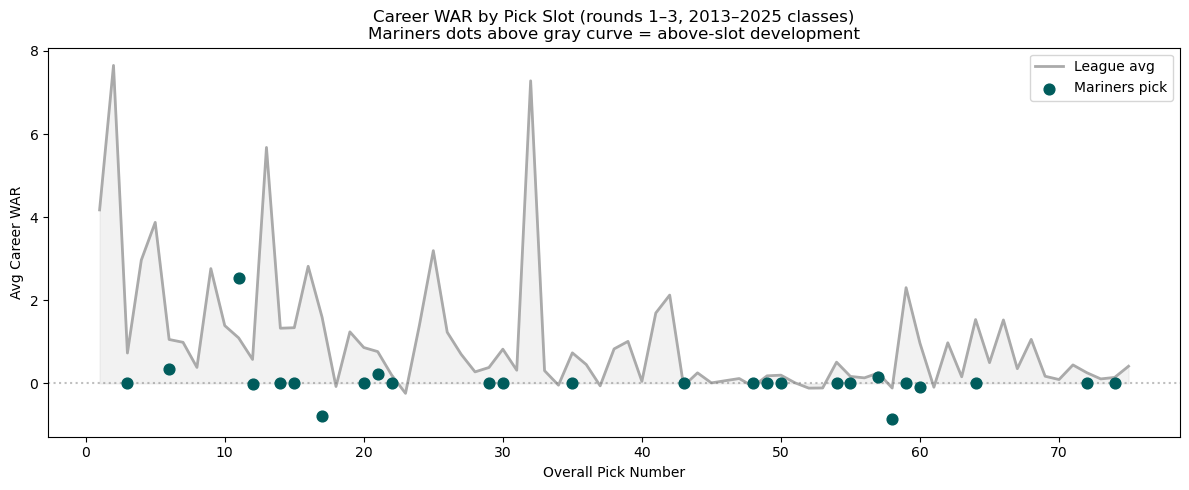

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(war_slot_df["pick_overall"], war_slot_df["slot_avg_war"],
        color="#AAAAAA", linewidth=2, label="League avg", zorder=2)
ax.fill_between(war_slot_df["pick_overall"], war_slot_df["slot_avg_war"],
                alpha=0.15, color="#AAAAAA")

sea = war_slot_df.dropna(subset=["sea_avg_war"])
ax.scatter(sea["pick_overall"], sea["sea_avg_war"],
           color="#005C5C", s=60, zorder=4, label="Mariners pick")

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Overall Pick Number")
ax.set_ylabel("Avg Career WAR")
ax.set_title("Career WAR by Pick Slot (rounds 1–3, 2013–2025 classes)\nMariners dots above gray curve = above-slot development")
ax.legend()
plt.tight_layout()
plt.show()

## 3 — Top Surplus-Value Mariners Picks

Mariners draftees (2013–2025) who generated the most WAR above what their pick slot
typically produces — the "steals" of the development pipeline.

In [6]:
surplus_df = con.execute("""
    WITH pick_war AS (
        SELECT
            dp.season          AS draft_year,
            dp.pick_overall,
            dp.round,
            dp.name_at_draft,
            dp.position,
            dp.mlbam_id,
            COALESCE(SUM(ps.war), 0)    AS career_war
        FROM draft_picks dp
        LEFT JOIN player_seasons ps USING (mlbam_id)
        WHERE dp.team = 'Mariners'
        GROUP BY dp.season, dp.pick_overall, dp.round, dp.name_at_draft,
                 dp.position, dp.mlbam_id
    ),
    slot_baseline AS (
        SELECT
            dp.pick_overall,
            AVG(COALESCE(ps_agg.career_war, 0))     AS slot_avg_war
        FROM draft_picks dp
        LEFT JOIN (
            SELECT mlbam_id, SUM(war) AS career_war
            FROM player_seasons
            GROUP BY mlbam_id
        ) ps_agg USING (mlbam_id)
        GROUP BY dp.pick_overall
    )
    SELECT
        pw.draft_year,
        pw.round,
        pw.pick_overall,
        pw.name_at_draft,
        pw.position,
        ROUND(pw.career_war, 1)                     AS career_war,
        ROUND(sb.slot_avg_war, 1)                   AS slot_avg_war,
        ROUND(pw.career_war - sb.slot_avg_war, 1)   AS war_surplus
    FROM pick_war pw
    JOIN slot_baseline sb USING (pick_overall)
    ORDER BY war_surplus DESC
    LIMIT 15
""").fetchdf()

print(surplus_df.to_string(index=False))

 draft_year  round  pick_overall   name_at_draft position  career_war  slot_avg_war  war_surplus
       2018      3            90    Cal Raleigh         C        23.1           2.1         21.0
       2013      3            85  Tyler O'Neill        RF        11.3           0.9         10.4
       2016      1            11     Kyle Lewis        OF         2.5           1.1          1.4
       2019     20           606   Cade Marlowe        LF         0.9           0.1          0.8
       2019      5           156 Austin Shenton        3B         0.3           0.0          0.2
       2018      5           148  Nolan Hoffman       RHP         0.0          -0.1          0.1
       2020      2            43   Zach DeLoach        OF         0.0          -0.1          0.1
       2014     18           531      Nick Kiel       LHP         0.0          -0.1          0.1
       2023      2            57 Ben Williamson        3B         0.3           0.3          0.1
       2018     17           5

## 4 — Time to MLB Debut

Average years from draft to first MLB appearance, by class.
2023–2025 classes are excluded — not enough time has elapsed for a fair comparison.

In [7]:
debut_df = con.execute("""
    WITH debut AS (
        SELECT
            dp.season                        AS draft_year,
            dp.team,
            dp.pick_overall,
            dp.name_at_draft,
            MIN(ps.season) - dp.season       AS years_to_debut
        FROM draft_picks dp
        JOIN player_seasons ps USING (mlbam_id)
        WHERE dp.season BETWEEN 2013 AND 2022
        GROUP BY dp.season, dp.team, dp.pick_overall, dp.name_at_draft
    ),
    league_avg AS (
        SELECT
            draft_year,
            ROUND(AVG(years_to_debut), 2)    AS league_avg_years,
            COUNT(*)                          AS league_n
        FROM debut
        GROUP BY draft_year
    ),
    mariners_avg AS (
        SELECT
            draft_year,
            ROUND(AVG(years_to_debut), 2)    AS sea_avg_years,
            COUNT(*)                          AS sea_n
        FROM debut
        WHERE team = 'Mariners'
        GROUP BY draft_year
    )
    SELECT
        l.draft_year,
        l.league_avg_years,
        l.league_n,
        m.sea_avg_years,
        m.sea_n
    FROM league_avg l
    LEFT JOIN mariners_avg m USING (draft_year)
    ORDER BY l.draft_year
""").fetchdf()

print(debut_df.to_string(index=False))

 draft_year  league_avg_years  league_n  sea_avg_years  sea_n
       2013              4.71       132           5.17      6
       2014              4.46       114           4.50      2
       2015              4.45       111           4.67      3
       2016              4.20       117           3.00      3
       2017              4.40       100           4.50      4
       2018              4.01        82           3.00      1
       2019              4.32        82           4.50      2
       2020              3.43        35           4.00      1
       2021              2.72        50           4.00      1
       2022              2.39        36           2.50      2


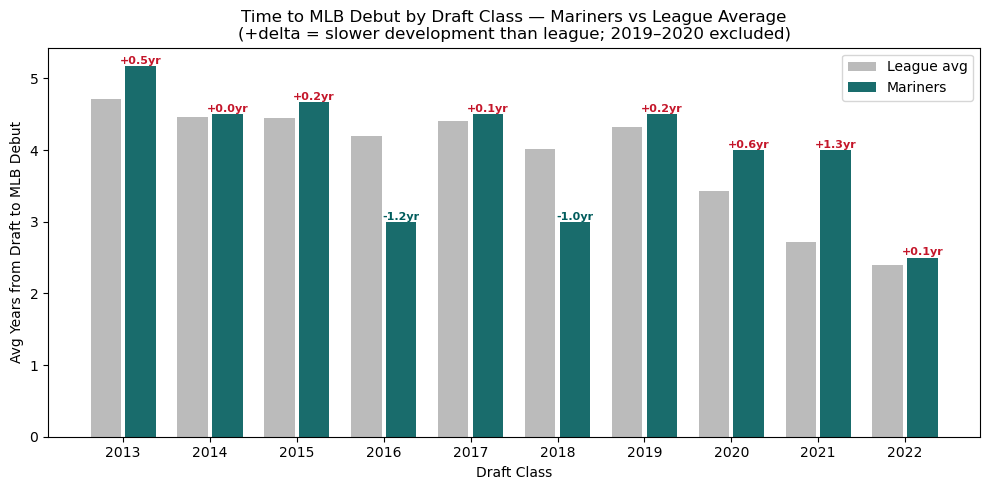

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(debut_df["draft_year"] - 0.2, debut_df["league_avg_years"],
       width=0.35, color="#AAAAAA", label="League avg", alpha=0.8)
ax.bar(debut_df["draft_year"] + 0.2, debut_df["sea_avg_years"].fillna(0),
       width=0.35, color="#005C5C", label="Mariners", alpha=0.9)

for _, row in debut_df.iterrows():
    if pd.notna(row["sea_avg_years"]) and row["sea_avg_years"] > 0:
        delta = row["sea_avg_years"] - row["league_avg_years"]
        color = "#C4162A" if delta > 0 else "#005C5C"
        ax.annotate(f"{delta:+.1f}yr",
                    (row["draft_year"] + 0.2, row["sea_avg_years"] + 0.03),
                    ha="center", fontsize=8, color=color, fontweight="bold")

ax.set_xlabel("Draft Class")
ax.set_ylabel("Avg Years from Draft to MLB Debut")
ax.set_title("Time to MLB Debut by Draft Class — Mariners vs League Average\n(+delta = slower development than league; 2019–2020 excluded)")
ax.set_xticks(debut_df["draft_year"])
ax.legend()
plt.tight_layout()
plt.show()

## 5 — Positional Pipeline Coverage

Per position, how much career WAR did Mariners draftees (2013–2025) generate vs the average team?
Positions below zero are structural gaps — the direct input to Pillar 3 FA targeting.

In [9]:
pipeline_gaps_df = con.execute("""
    WITH pos_norm AS (
        SELECT
            dp.mlbam_id,
            dp.team,
            CASE
                WHEN dp.position IN ('LHP','RHP','SP','RP','P') THEN 'P'
                WHEN dp.position IN ('LF','CF','RF','OF')       THEN 'OF'
                WHEN dp.position = 'C'                          THEN 'C'
                WHEN dp.position = '1B'                         THEN '1B'
                WHEN dp.position = '2B'                         THEN '2B'
                WHEN dp.position = '3B'                         THEN '3B'
                WHEN dp.position = 'SS'                         THEN 'SS'
                ELSE NULL
            END AS pos_group
        FROM draft_picks dp
        WHERE dp.season BETWEEN 2013 AND 2025
    ),
    war_by_pos_team AS (
        SELECT
            pn.pos_group,
            pn.team,
            ROUND(SUM(COALESCE(ps.war, 0)), 1)                              AS total_war,
            COUNT(DISTINCT pn.mlbam_id) FILTER (WHERE pn.mlbam_id IS NOT NULL) AS n_players
        FROM pos_norm pn
        LEFT JOIN player_seasons ps USING (mlbam_id)
        WHERE pn.pos_group IS NOT NULL
        GROUP BY pn.pos_group, pn.team
    ),
    league_avg AS (
        SELECT
            pos_group,
            ROUND(AVG(total_war), 1)    AS league_avg_war
        FROM war_by_pos_team
        GROUP BY pos_group
    )
    SELECT
        l.pos_group,
        l.league_avg_war                                        AS league_avg_war_per_team,
        COALESCE(m.total_war, 0)                                AS sea_war,
        COALESCE(m.n_players, 0)                                AS sea_players,
        ROUND(COALESCE(m.total_war, 0) - l.league_avg_war, 1)  AS war_vs_league,
        CASE WHEN COALESCE(m.total_war, 0) < l.league_avg_war
             THEN TRUE ELSE FALSE END                           AS is_gap
    FROM league_avg l
    LEFT JOIN war_by_pos_team m
           ON l.pos_group = m.pos_group AND m.team = 'Mariners'
    ORDER BY war_vs_league ASC
""").fetchdf()

print(pipeline_gaps_df.to_string(index=False))

pos_group  league_avg_war_per_team  sea_war  sea_players  war_vs_league  is_gap
       SS                     14.7     -0.9            5          -15.6    True
       3B                      5.6     -0.3            3           -5.9    True
       1B                      3.1     -0.8            1           -3.9    True
       2B                      2.9      0.0            0           -2.9    True
       OF                     16.7     14.5            7           -2.2    True
        P                      0.5     -0.4           31           -0.9    True
        C                      7.6     23.0            3           15.4   False


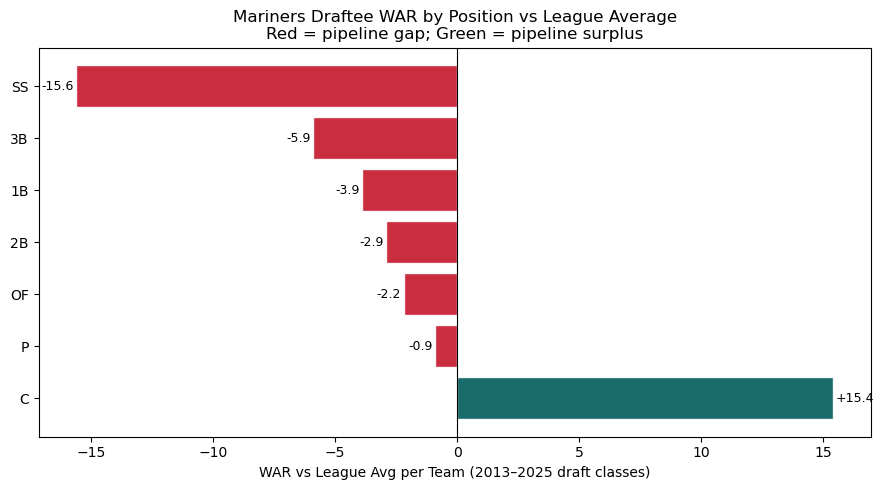

Pipeline gaps (below league avg): ['SS', '3B', '1B', '2B', 'OF', 'P']


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#C4162A" if g else "#005C5C" for g in pipeline_gaps_df["is_gap"]]
bars = ax.barh(pipeline_gaps_df["pos_group"], pipeline_gaps_df["war_vs_league"],
               color=colors, edgecolor="white", alpha=0.9)

ax.axvline(0, color="black", linewidth=0.8)

for bar, val in zip(bars, pipeline_gaps_df["war_vs_league"]):
    ax.text(val + (0.1 if val >= 0 else -0.1), bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

ax.set_xlabel("WAR vs League Avg per Team (2013–2025 draft classes)")
ax.set_title("Mariners Draftee WAR by Position vs League Average\nRed = pipeline gap; Green = pipeline surplus")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

gap_positions = pipeline_gaps_df.loc[pipeline_gaps_df["is_gap"], "pos_group"].tolist()
print(f"Pipeline gaps (below league avg): {gap_positions}")

## 6 — Draft Class Development Curve

Cumulative WAR per draftee (rounds 1–10) by years since draft, Mariners vs league average.
Shows whether recent classes are tracking ahead or behind historical development rates.
2023–2025 classes excluded — insufficient elapsed time.

In [11]:
dev_curve_df = con.execute("""
    WITH yearly_war AS (
        SELECT
            dp.season                     AS draft_class,
            dp.team,
            dp.mlbam_id,
            ps.season - dp.season         AS years_elapsed,
            ps.war
        FROM draft_picks dp
        JOIN player_seasons ps USING (mlbam_id)
        WHERE dp.season BETWEEN 2013 AND 2022
          AND ps.season - dp.season BETWEEN 0 AND 9
          AND dp.round <= 10
    ),
    cohort_size AS (
        SELECT season AS draft_class, team, COUNT(DISTINCT mlbam_id) AS n_players
        FROM draft_picks
        WHERE season BETWEEN 2013 AND 2022
          AND round <= 10
          AND mlbam_id IS NOT NULL
        GROUP BY season, team
    ),
    team_year_war AS (
        SELECT draft_class, team, years_elapsed, SUM(war) AS total_war
        FROM yearly_war
        GROUP BY draft_class, team, years_elapsed
    ),
    max_year AS (
        SELECT draft_class, MAX(years_elapsed) AS max_ye
        FROM team_year_war
        GROUP BY draft_class
    ),
    year_grid AS (
        SELECT cs.draft_class, cs.team, g.years_elapsed
        FROM cohort_size cs
        CROSS JOIN (SELECT UNNEST(GENERATE_SERIES(0, 9)) AS years_elapsed) g
        JOIN max_year my ON cs.draft_class = my.draft_class
        WHERE g.years_elapsed <= my.max_ye
    ),
    filled AS (
        SELECT yg.draft_class, yg.team, yg.years_elapsed,
               COALESCE(tyw.total_war, 0) AS total_war
        FROM year_grid yg
        LEFT JOIN team_year_war tyw USING (draft_class, team, years_elapsed)
    ),
    with_cumulative AS (
        SELECT
            f.draft_class,
            f.team,
            f.years_elapsed,
            SUM(f.total_war / cs.n_players) OVER (
                PARTITION BY f.draft_class, f.team
                ORDER BY f.years_elapsed
            ) AS cum_war_per_draftee
        FROM filled f
        JOIN cohort_size cs USING (draft_class, team)
    ),
    league_curve AS (
        SELECT draft_class, years_elapsed,
               AVG(cum_war_per_draftee) AS league_avg_cum_war
        FROM with_cumulative
        GROUP BY draft_class, years_elapsed
    ),
    mariners_curve AS (
        SELECT draft_class, years_elapsed, cum_war_per_draftee AS sea_cum_war
        FROM with_cumulative
        WHERE team = 'Mariners'
    )
    SELECT
        l.draft_class,
        l.years_elapsed,
        ROUND(l.league_avg_cum_war, 3) AS league_avg_cum_war,
        ROUND(m.sea_cum_war, 3)        AS sea_cum_war
    FROM league_curve l
    LEFT JOIN mariners_curve m USING (draft_class, years_elapsed)
    ORDER BY draft_class, years_elapsed
""").fetchdf()

print(dev_curve_df.to_string(index=False))

 draft_class  years_elapsed  league_avg_cum_war  sea_cum_war
        2013              0               0.000        0.000
        2013              1               0.000        0.000
        2013              2               0.045        0.000
        2013              3               0.126        0.000
        2013              4               0.440       -0.023
        2013              5               0.650        0.183
        2013              6               1.066        0.210
        2013              7               1.209        0.261
        2013              8               1.526        1.324
        2013              9               2.028        1.630
        2014              0               0.000        0.000
        2014              1               0.021        0.000
        2014              2               0.157        0.000
        2014              3               0.353        0.000
        2014              4               0.673       -0.010
        2014            

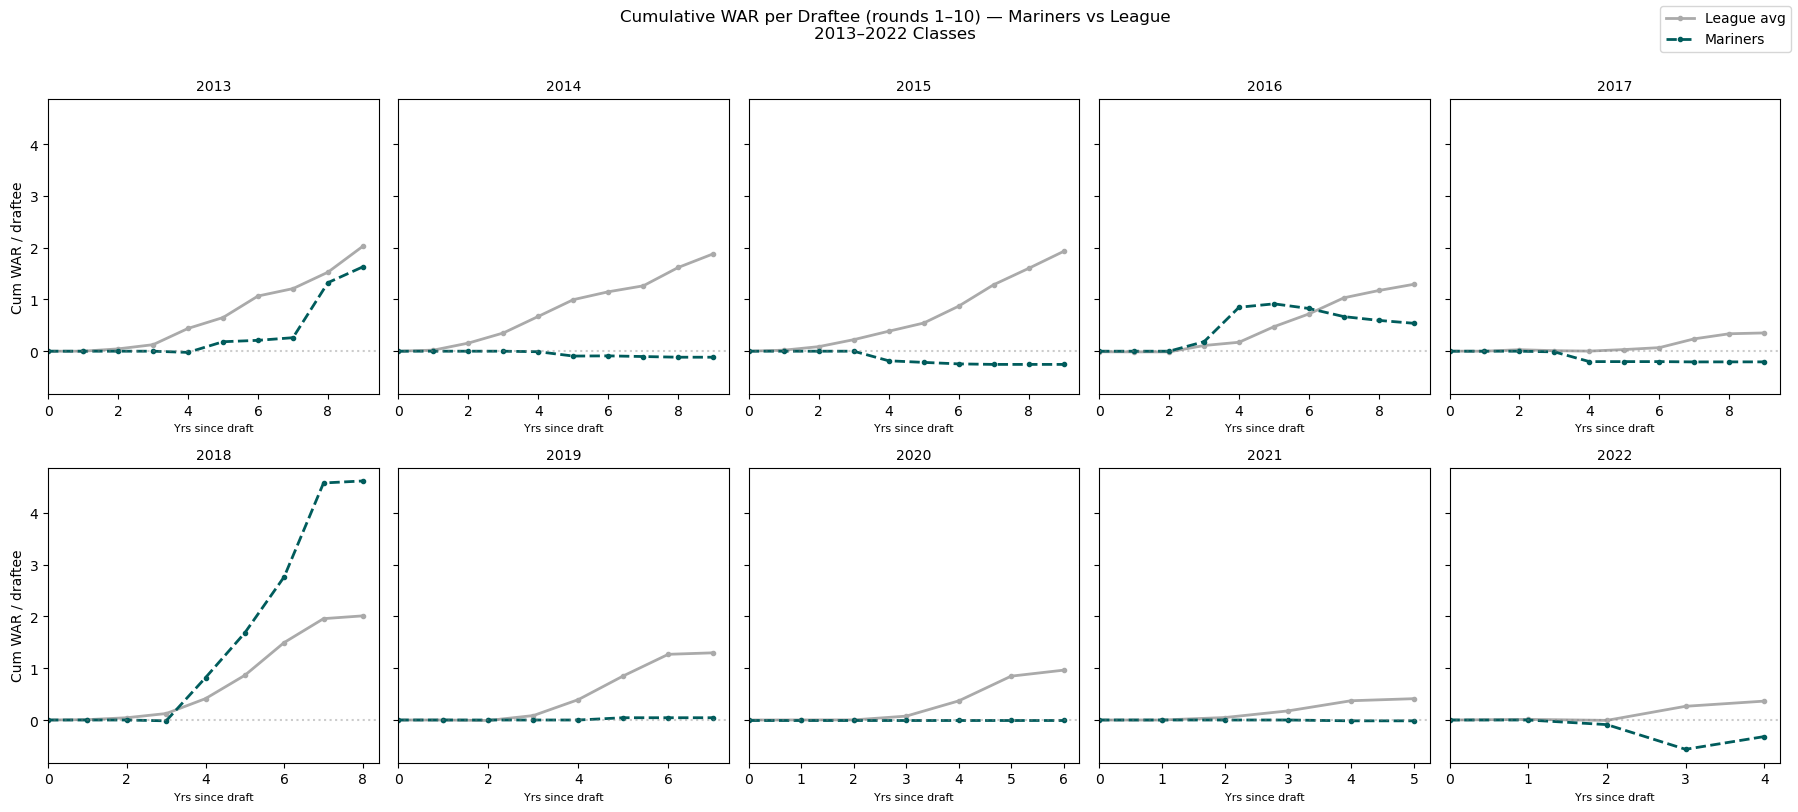

In [12]:
classes = sorted(dev_curve_df["draft_class"].unique())
n_classes = len(classes)
ncols = 5
nrows = -(-n_classes // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
axes_flat = list(axes.flat)

for ax, cls in zip(axes_flat, classes):
    sub = dev_curve_df[dev_curve_df["draft_class"] == cls]
    ax.plot(sub["years_elapsed"], sub["league_avg_cum_war"],
            color="#AAAAAA", linewidth=2, marker="o", markersize=3, label="League avg")
    ax.plot(sub["years_elapsed"], sub["sea_cum_war"],
            color="#005C5C", linewidth=2, linestyle="--", marker="o", markersize=3, label="Mariners")
    ax.axhline(0, color="gray", linestyle=":", alpha=0.4)
    ax.set_xlim(left=0)
    ax.set_title(str(cls), fontsize=10)
    ax.set_xlabel("Yrs since draft", fontsize=8)

for ax in axes_flat[n_classes:]:
    ax.set_visible(False)

for r in range(nrows):
    axes_flat[r * ncols].set_ylabel("Cum WAR / draftee")

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Cumulative WAR per Draftee (rounds 1–10) — Mariners vs League\n2013–2022 Classes", y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# --- Export to Tableau / Pillar 3 input ---
export_reach     = "../dashboard/tableau_data_extracts/draft_reach_rate.csv"
export_surplus   = "../dashboard/tableau_data_extracts/draft_surplus.csv"
export_debut     = "../dashboard/tableau_data_extracts/draft_debut_lag.csv"
export_gaps      = "../dashboard/tableau_data_extracts/pipeline_gaps.csv"
export_dev_curve = "../dashboard/tableau_data_extracts/draft_dev_curve.csv"

reach_df.to_csv(export_reach, index=False)
surplus_df.to_csv(export_surplus, index=False)
debut_df.to_csv(export_debut, index=False)
pipeline_gaps_df.to_csv(export_gaps, index=False)
dev_curve_df.to_csv(export_dev_curve, index=False)

print(f"Exported reach rate     → {export_reach}")
print(f"Exported surplus WAR    → {export_surplus}")
print(f"Exported debut lag      → {export_debut}")
print(f"Exported pipeline gaps  → {export_gaps}")
print(f"Exported dev curve      → {export_dev_curve}")
print(f"\nPillar 3 will filter FA targets to: {gap_positions}")

Exported reach rate     → ../dashboard/tableau_data_extracts/draft_reach_rate.csv
Exported surplus WAR    → ../dashboard/tableau_data_extracts/draft_surplus.csv
Exported debut lag      → ../dashboard/tableau_data_extracts/draft_debut_lag.csv
Exported pipeline gaps  → ../dashboard/tableau_data_extracts/pipeline_gaps.csv
Exported dev curve      → ../dashboard/tableau_data_extracts/draft_dev_curve.csv

Pillar 3 will filter FA targets to: ['SS', '3B', '1B', '2B', 'OF', 'P']
